**PRE PROCESSING WHIHC INCLUDES TRANSLATION OF SOME USER TWEETS IN ENGLISH**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd


df = pd.read_csv('/content/drive/MyDrive/AI/cleaned_tweets_fixed_datetime.csv')

# Ensure that the date column is in datetime format (if it's not already)
df['date_column'] = pd.to_datetime(df['time_date'])

# Filter out rows from the year 2022 and where the user_name is 'Kenye West'
df_cleaned = df[(df['date_column'].dt.year == 2022) & (df['user_name'] != 'Kenye West')]

df_cleaned.to_csv('/content/drive/MyDrive/AI/cleaned_tweets_kenye.csv', index=False)

# Show the first few rows of the cleaned data
print("Dataset after removing 2022 tweets and 'Kenye West' rows:")
print(df_cleaned.head())


Dataset after removing 2022 tweets and 'Kenye West' rows:
           user_name      tone            time_date  \
124075  ImranKhanPTI  negative  2022-10-30 14:07:08   
124076  ImranKhanPTI  positive  2022-10-29 17:37:22   
124077  ImranKhanPTI   neutral  2022-10-28 18:43:41   
124078  ImranKhanPTI  positive  2022-10-24 11:28:55   
124079  ImranKhanPTI  negative  2022-10-24 11:28:54   

                                                     text         date_column  
124075  shocked amp deeply saddened by the terrible ac... 2022-10-30 14:07:08  
124076  for all those spreading rumours about my mtg i... 2022-10-29 17:37:22  
124077  congratulations to abid zuberi on his election... 2022-10-28 18:43:41  
124078  we saw a foreign abetted regime change conspir... 2022-10-24 11:28:55  
124079  amp safeguarded against excesses by the state ... 2022-10-24 11:28:54  


In [ ]:
import pandas as pd
from googletrans import Translator

# Load the cleaned dataset
df_cleaned = pd.read_csv('/content/drive/MyDrive/AI/cleaned_tweets_kenye.csv')

# Initialize the translator
translator = Translator()

# Function to translate text if it's not already in English
def translate_text(tweet):
    try:
        # Translate to English
        translated = translator.translate(tweet, src='auto', dest='en')
        return translated.text
    except Exception as e:
        print(f"Error during translation: {e}")
        return tweet  # Return original tweet if there's an error

# Apply translation to Ronaldo's tweets and update the 'text' column
df_cleaned['text'] = df_cleaned.apply(
    lambda row: translate_text(row['text']) if row['user_name'] == 'cristiano ronaldo' else row['text'], axis=1
)

# Optionally, save the modified dataset with translated tweets to a new CSV file
df_cleaned.to_csv('/content/drive/MyDrive/AI/cleaned_tweets_with_translations.csv', index=False)

# Show the first few rows of the updated dataset
print(df_cleaned.head())


      user_name      tone            time_date  \
0  ImranKhanPTI  negative  2022-10-30 14:07:08   
1  ImranKhanPTI  positive  2022-10-29 17:37:22   
2  ImranKhanPTI   neutral  2022-10-28 18:43:41   
3  ImranKhanPTI  positive  2022-10-24 11:28:55   
4  ImranKhanPTI  negative  2022-10-24 11:28:54   

                                                text          date_column  
0  shocked amp deeply saddened by the terrible ac...  2022-10-30 14:07:08  
1  for all those spreading rumours about my mtg i...  2022-10-29 17:37:22  
2  congratulations to abid zuberi on his election...  2022-10-28 18:43:41  
3  we saw a foreign abetted regime change conspir...  2022-10-24 11:28:55  
4  amp safeguarded against excesses by the state ...  2022-10-24 11:28:54  


In [ ]:
import pandas as pd

# Assuming your dataset is already loaded into 'df'

# Remove rows with NaN values
df_cleaned = df.dropna()

# Group by 'user_name' and count the number of tweets for each user
tweet_counts = df_cleaned.groupby('user_name')['text'].count()

# Display the tweet count for each user
print("Tweet count for each user:")
print(tweet_counts)


Tweet count for each user:
user_name
Elon Musk            2527
ImranKhanPTI          267
cristiano ronaldo      33
Name: text, dtype: int64


Outliers Removed:
    user_name  tweet_count
2  Kenye West        22718

Data without outliers:
           user_name  tweet_count
0          Elon Musk         2527
1       ImranKhanPTI          267
3  Cristiano Ronaldo           33


**MODEL TRAINING**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import defaultdict

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/AI/cleaned_tweets_with_translations.csv')

# Encode sentiment (tone) labels to numeric values
le = LabelEncoder()
df['tone'] = le.fit_transform(df['tone'])  # Positive = 1, Neutral = 0, Negative = 2 (or any other mapping you choose)

# Prepare user-specific data
user_data = defaultdict(list)

# Group tweets by user
for _, row in df.iterrows():
    user_data[row['user_name']].append((row['text'], row['tone']))

# Example user data (for demonstration)
print(user_data)


defaultdict(<class 'list'>, {'ImranKhanPTI': [('shocked amp deeply saddened by the terrible accident that led to the death of channel reporter sadaf naeem during our march today i have no words to express my sorrow my prayers amp condolences go to the family at this tragic time we have cancelled our march for today', 0), ('for all those spreading rumours about my mtg in lahore the reason we returned was bec lahore was closer amp we had already decided not move at night the only demand i have had for mths is date for early fair amp free elections that will be the only demand if talks are to be held', 2), ('congratulations to abid zuberi on his election as president scba', 1), ('we saw a foreign abetted regime change conspiracy taking place sending pak into chaos but senior judiciary continues to remain aloof when will the judiciary move to act against state institutions that are defying all laws amp violating the constitution it is high time they did', 2), ('amp safeguarded against exce

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout
import pickle
from collections import defaultdict

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/AI/cleaned_tweets_with_translations.csv')

# Encode sentiment (tone) labels to numeric values
le = LabelEncoder()
df['tone'] = le.fit_transform(df['tone'])  # Positive = 1, Neutral = 0, Negative = 2

# Group tweets by user
user_data = defaultdict(list)
for _, row in df.iterrows():
    user_data[row['user_name']].append((row['text'], row['tone']))

# Define the path where models will be saved
save_directory = '/content/drive/MyDrive/AI/trainfiles/'

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

# Preprocess data for each user
user_models = {}
user_tokenizers = {}
user_label_encoders = {}

for user, tweets in user_data.items():
    # Extract texts and labels
    texts, labels = zip(*tweets)

    # Convert all texts to strings (in case there are any non-string values)
    texts = [str(text) if isinstance(text, str) else "" for text in texts]

    # Tokenizer for each user
    tokenizer = Tokenizer(num_words=5000)
    tokenizer.fit_on_texts(texts)

    # Convert texts to sequences
    sequences = tokenizer.texts_to_sequences(texts)

    # Pad sequences to the same length (maxlen=56)
    maxlen = 56
    padded_sequences = pad_sequences(sequences, padding='post', maxlen=maxlen)

    # Split data into training and testing for each user
    X_train, X_test, y_train, y_test = train_test_split(padded_sequences, np.array(labels), test_size=0.2, random_state=42)

    # Build the LSTM model for this user
    model = Sequential()
    model.add(Embedding(input_dim=5000, output_dim=128, input_length=maxlen))
    model.add(LSTM(128, return_sequences=False))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))  # 3 classes for positive, neutral, and negative

    # Compile the model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Train the model for the user
    model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

    # Save model for the user in the "trainfiles" folder
    model_filename = os.path.join(save_directory, f"{user}_sentiment_model.h5")
    model.save(model_filename)

    # Save tokenizer for the user
    tokenizer_filename = os.path.join(save_directory, f"{user}_tokenizer.pkl")
    with open(tokenizer_filename, 'wb') as f:
        pickle.dump(tokenizer, f)

    # Save label encoder for the user (in case you want to use original tone labels later)
    label_encoder_filename = os.path.join(save_directory, f"{user}_label_encoder.pkl")
    with open(label_encoder_filename, 'wb') as f:
        pickle.dump(le, f)

    # Store user models, tokenizers, and label encoders in dictionaries
    user_models[user] = model
    user_tokenizers[user] = tokenizer
    user_label_encoders[user] = le

# Example usage: Predict sentiment for a new tweet from a specific user
def predict_sentiment(user_name, new_tweet):
    # Load the user's model and tokenizer from the "trainfiles" folder
    model_filename = os.path.join(save_directory, f"{user_name}_sentiment_model.h5")
    tokenizer_filename = os.path.join(save_directory, f"{user_name}_tokenizer.pkl")
    label_encoder_filename = os.path.join(save_directory, f"{user_name}_label_encoder.pkl")

    # Load the model, tokenizer, and label encoder
    model = tf.keras.models.load_model(model_filename)
    with open(tokenizer_filename, 'rb') as f:
        tokenizer = pickle.load(f)
    with open(label_encoder_filename, 'rb') as f:
        le = pickle.load(f)

    # Tokenize the new tweet
    sequences = tokenizer.texts_to_sequences([new_tweet])
    padded_seq = pad_sequences(sequences, padding='post', maxlen=56)

    # Predict sentiment
    prediction = model.predict(padded_seq)
    sentiment = np.argmax(prediction, axis=1)  # Get the class with highest probability

    # Convert numeric label back to sentiment text
    sentiment_label = le.inverse_transform(sentiment)
    return sentiment_label[0]

# Test prediction for 'lionel messi'
new_tweet = "Nawaz Shareef is the greatest of all time"
predicted_sentiment = predict_sentiment('ImranKhanPTI', new_tweet)
print(f"The predicted sentiment for the tweet is: {predicted_sentiment}")


Epoch 1/15


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.4870 - loss: 1.0756 - val_accuracy: 0.5556 - val_loss: 1.0307
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.4975 - loss: 1.0218 - val_accuracy: 0.5556 - val_loss: 1.0201
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5147 - loss: 1.0060 - val_accuracy: 0.5556 - val_loss: 1.0252
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.4862 - loss: 1.0426 - val_accuracy: 0.5556 - val_loss: 1.0328
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5020 - loss: 1.0167 - val_accuracy: 0.5556 - val_loss: 1.0409
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.5113 - loss: 0.9614 - val_accuracy: 0.5185 - val_loss: 1.0827
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.6387 - loss: 0.7471 - val_accuracy: 0.4074 - val_loss: 1.2037
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.8208 - loss: 0.4904 - val_accuracy: 0.3333 - val_loss: 1.5508
Epo

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.4234 - loss: 1.0323 - val_accuracy: 0.4447 - val_loss: 1.0190
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.4514 - loss: 1.0229 - val_accuracy: 0.4447 - val_loss: 1.0153
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.4551 - loss: 1.0065 - val_accuracy: 0.4447 - val_loss: 1.0207
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.4278 - loss: 1.0043 - val_accuracy: 0.4447 - val_loss: 1.0174
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.4448 - loss: 1.0071 - val_accuracy: 0.4447 - val_loss: 1.0156
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.4416 - loss: 1.0102 - val_accuracy: 0.4447 - val_loss: 1.0228
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.4255 - loss: 0.9971 - val_accuracy: 0.4447 - val_loss: 1.0152
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.4485 - loss: 0.9916 - val_accuracy: 0.

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2692 - loss: 1.1058 - val_accuracy: 0.5714 - val_loss: 1.0474
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step - accuracy: 0.4615 - loss: 1.0570 - val_accuracy: 0.5714 - val_loss: 0.9982
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.4615 - loss: 1.0116 - val_accuracy: 0.5714 - val_loss: 0.9455
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6154 - loss: 0.9691 - val_accuracy: 0.5714 - val_loss: 0.8870
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6538 - loss: 0.9257 - val_accuracy: 0.5714 - val_loss: 0.8249
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5769 - loss: 0.8792 - val_accuracy: 0.5714 - val_loss: 0.7685
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.4615 - loss: 0.8711 - val_accuracy: 0.2857 - val_loss: 0.7370
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.4615 - loss: 0.8349 - val_accuracy: 0.4286 - val_loss: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
The predicted sentiment for the tweet is: negative


**Model Testing**

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


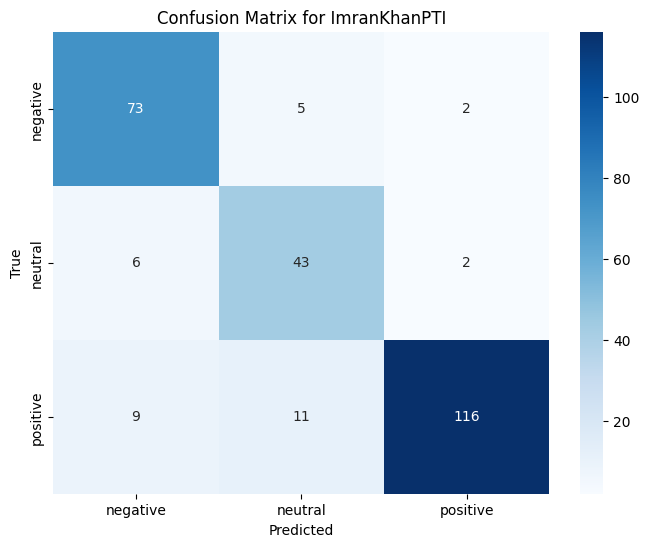

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


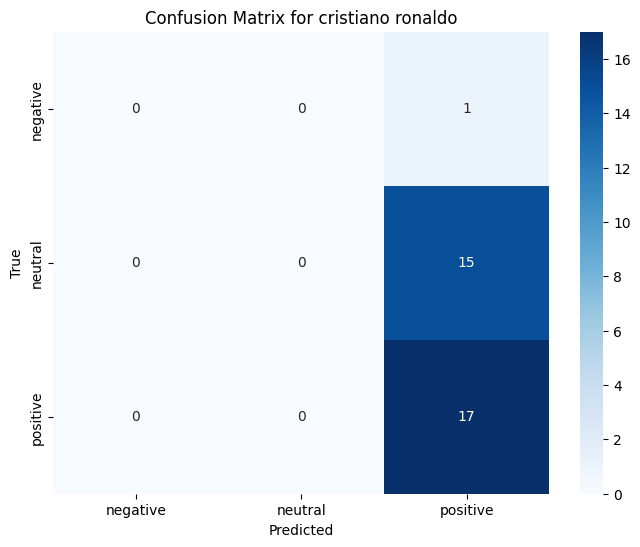

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step


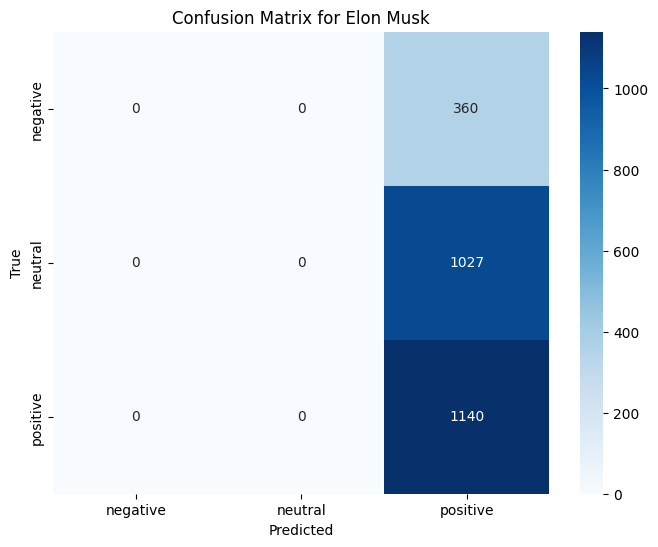

In [ ]:
import os
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix
from collections import defaultdict

# Path where models and tokenizers are saved
save_directory = '/content/drive/MyDrive/AI/trainfiles/'

# Function to load model and tokenizer for the selected user
def load_user_model(user_name):
    model_filename = os.path.join(save_directory, f"{user_name}_sentiment_model.h5")
    tokenizer_filename = os.path.join(save_directory, f"{user_name}_tokenizer.pkl")
    label_encoder_filename = os.path.join(save_directory, f"{user_name}_label_encoder.pkl")

    if os.path.exists(model_filename) and os.path.exists(tokenizer_filename) and os.path.exists(label_encoder_filename):
        # Load the model, tokenizer, and label encoder
        model = tf.keras.models.load_model(model_filename)
        with open(tokenizer_filename, 'rb') as f:
            tokenizer = pickle.load(f)
        with open(label_encoder_filename, 'rb') as f:
            le = pickle.load(f)
        return model, tokenizer, le
    else:
        print(f"Error: Model files for user {user_name} not found.")
        return None, None, None

# Function to generate confusion matrix for each user
def generate_confusion_matrix(user_name):
    model, tokenizer, le = load_user_model(user_name)

    if model is None:
        return

    # Prepare data: Assuming user_data dictionary is already available
    user_data = defaultdict(list)  # Replace with actual user data
    for _, row in df.iterrows():
        user_data[row['user_name']].append((row['text'], row['tone']))

    # Tokenize and pad sequences
    texts, labels = zip(*user_data[user_name])

    # Clean the texts (convert any NaN or non-string values to an empty string)
    texts = [str(text) if isinstance(text, str) else "" for text in texts]

    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, padding='post', maxlen=56)

    # Make predictions
    predictions = model.predict(padded_sequences)
    predicted_labels = np.argmax(predictions, axis=1)

    # Generate confusion matrix
    cm = confusion_matrix(labels, predicted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix for {user_name}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Example of generating confusion matrix for a specific user
user_names = ['ImranKhanPTI', 'cristiano ronaldo', 'Elon Musk']  # Example users, replace with actual ones
for user in user_names:
    generate_confusion_matrix(user)


In [ ]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Path where models and tokenizers are saved
save_directory = '/content/drive/MyDrive/AI/trainfiles/'
def predict_sentiment(user_name, new_tweet):
    try:
        # Load the user's model, tokenizer, and label encoder
        model_filename = os.path.join(save_directory, f"{user_name}_sentiment_model.h5")
        tokenizer_filename = os.path.join(save_directory, f"{user_name}_tokenizer.pkl")
        label_encoder_filename = os.path.join(save_directory, f"{user_name}_label_encoder.pkl")

        # Load the model
        model = tf.keras.models.load_model(model_filename)

        # Load the tokenizer
        with open(tokenizer_filename, 'rb') as f:
            tokenizer = pickle.load(f)

        # Load the label encoder
        with open(label_encoder_filename, 'rb') as f:
            le = pickle.load(f)

        # Tokenize the new tweet
        sequences = tokenizer.texts_to_sequences([new_tweet])
        padded_seq = pad_sequences(sequences, padding='post', maxlen=56)

        # Predict sentiment
        prediction = model.predict(padded_seq)
        sentiment = np.argmax(prediction, axis=1)  # Get the class with the highest probability

        # Convert numeric label back to sentiment text
        sentiment_label = le.inverse_transform(sentiment)
        return sentiment_label[0]

    except Exception as e:
        return f"Error: {e}"

# User input
user_name = input("Enter the user name (e.g.,ImranKhanPTI', 'cristiano ronaldo', 'Elon Musk'): ").strip()
new_tweet = input("Enter the tweet: ").strip()

if new_tweet:
    predicted_sentiment = predict_sentiment(user_name, new_tweet)
    print(f"The predicted sentiment for the tweet is: {predicted_sentiment}")
else:
    print("Error: Please provide a valid tweet.")


Enter the user name (e.g.,ImranKhanPTI', 'cristiano ronaldo', 'Elon Musk'): ImranKhanPTI
Enter the tweet: Nawaz Sharif's government led to significant corruption scandals.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
The predicted sentiment for the tweet is: neutral
